In [1]:
# ==============================
# 1) EXTRACT ZIP + IMPORTS
# ==============================

import os
import re
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

print("PyTorch version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

# -------- Extract archive.zip --------
zip_path = "archive.zip"
extract_path = "extracted_data"

if not os.path.exists(extract_path):
    os.makedirs(extract_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP extracted successfully!")
print("Files inside extracted_data:")
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

PyTorch version: 2.11.0+cpu
GPU Available: False
ZIP extracted successfully!
Files inside extracted_data:
extracted_data\IMDB Dataset.csv


In [2]:
# ==============================
# 2) FIND CSV FILE AUTOMATICALLY
# ==============================

csv_files = []

for root, dirs, files in os.walk("extracted_data"):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")
for i, f in enumerate(csv_files):
    print(f"{i}: {f}")

# If multiple CSVs exist, choose one manually by index
# Example: file_path = csv_files[0]
file_path = csv_files[0]

print("\nUsing file:", file_path)

CSV files found:
0: extracted_data\IMDB Dataset.csv

Using file: extracted_data\IMDB Dataset.csv


In [3]:
# ==============================
# 3) LOAD DATASET
# ==============================

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset loaded successfully!
Shape: (50000, 2)

Columns:
['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
# ==============================
# 4) DETECT TEXT + LABEL COLUMNS
# ==============================

# Convert column names to lowercase for easy matching
lower_cols = {col.lower(): col for col in df.columns}

text_col = None
label_col = None

possible_text_cols = ['text', 'tweet', 'tweet content', 'review', 'comment', 'sentence']
possible_label_cols = ['label', 'sentiment', 'target', 'class']

for col in df.columns:
    if col.lower() in possible_text_cols:
        text_col = col
    if col.lower() in possible_label_cols:
        label_col = col

print("Detected text column:", text_col)
print("Detected label column:", label_col)

# -------- If automatic detection fails, set manually here --------
# Example:
# text_col = "Tweet content"
# label_col = "Sentiment"

if text_col is None or label_col is None:
    print("\n⚠️ Automatic detection failed.")
    print("Please manually set these two lines below and run again:")
    print('text_col = "your_text_column_name"')
    print('label_col = "your_label_column_name"')
else:
    print("\nColumns detected successfully!")

Detected text column: review
Detected label column: sentiment

Columns detected successfully!


In [5]:
# ==============================
# 5) KEEP ONLY TEXT + LABEL
# ==============================

df = df[[text_col, label_col]].copy()
df.columns = ["text", "label"]

print(df.head())
print("\nMissing values before cleaning:")
print(df.isnull().sum())

                                                text     label
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Missing values before cleaning:
text     0
label    0
dtype: int64


In [6]:
# ==============================
# 6) CLEAN DATA
# ==============================

df.dropna(inplace=True)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)        # remove URLs
    text = re.sub(r"@\w+", "", text)           # remove mentions
    text = re.sub(r"#\w+", "", text)           # remove hashtags
    text = re.sub(r"[^a-zA-Z ]", "", text)     # keep only letters
    text = re.sub(r"\s+", " ", text).strip()   # remove extra spaces
    return text

df["text"] = df["text"].apply(clean_text)

# Remove empty rows after cleaning
df = df[df["text"].str.len() > 0]

print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (50000, 2)


,text,label
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production br br the filmin...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


In [7]:
# ==============================
# 7) ENCODE LABELS
# ==============================

print("Original labels:")
print(df["label"].value_counts())

df["label"] = df["label"].astype("category")
label_mapping = dict(enumerate(df["label"].cat.categories))
reverse_mapping = {v:k for k,v in label_mapping.items()}
df["label"] = df["label"].cat.codes

print("\nEncoded label mapping:")
print(label_mapping)

print("\nSample:")
df.head()

Original labels:
label
positive    25000
negative    25000
Name: count, dtype: int64

Encoded label mapping:
{0: 'negative', 1: 'positive'}

Sample:


,text,label
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production br br the filmin...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1


In [8]:
# ==============================
# 8) REDUCE SIZE FOR SPEED
# ==============================

# Change 2000 to 1000 if your laptop is slow
sample_size = min(2000, len(df))
df = df.sample(sample_size, random_state=42)

print("Using rows:", len(df))
print(df["label"].value_counts())

Using rows: 2000
label
0    1024
1     976
Name: count, dtype: int64


In [9]:
# ==============================
# 9) TRAIN / TEST SPLIT
# ==============================

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", len(train_texts))
print("Validation samples:", len(val_texts))

Training samples: 1600
Validation samples: 400


In [10]:
# ==============================
# 10) PYTORCH DATASET CLASS
# ==============================

class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [11]:
# ==============================
# 11) TOKENIZE FOR BERT
# ==============================

distil_tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

train_encodings = distil_tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = distil_tokenizer(val_texts, truncation=True, padding=True, max_length=128)

train_dataset = TextDataset(train_encodings, train_labels)
val_dataset = TextDataset(val_encodings, val_labels)

print("Tokenization complete!")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenization complete!


In [12]:
# ==============================
# 12) LOAD BERT MODEL
# ==============================

num_labels = len(set(train_labels))

distil_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
)

print("DistilBERT model loaded!")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded!


In [13]:
# ==============================
# 13) TRAINING SETTINGS
# ==============================

distil_args = TrainingArguments(
    output_dir="./distilbert_results",
    num_train_epochs=2,              # keep small for speed
    per_device_train_batch_size=8,   # reduce to 4 if RAM issue
    per_device_eval_batch_size=8,
    logging_dir="./logs_distil",
    logging_steps=20,
    save_strategy="no",
    eval_strategy="epoch",
    report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [14]:
# ==============================
# 14) TRAIN model
# ==============================

distil_trainer = Trainer(
    model=distil_model,
    args=distil_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

print("Training DistilBERT...")
distil_trainer.train()
print("Training completed!")

Training DistilBERT...


Epoch,Training Loss,Validation Loss
1,0.420101,0.427533
2,0.195084,0.508792


Training completed!


In [15]:
# ==============================
# 15) EVALUATE 
# ==============================

distil_preds = distil_trainer.predict(val_dataset)
distil_y_pred = np.argmax(distil_preds.predictions, axis=1)

distil_acc = accuracy_score(val_labels, distil_y_pred)
distil_precision, distil_recall, distil_f1, _ = precision_recall_fscore_support(
    val_labels, distil_y_pred, average="weighted"
)

print("===== DISTILBERT RESULTS =====")
print("Accuracy :", distil_acc)
print("Precision:", distil_precision)
print("Recall   :", distil_recall)
print("F1 Score :", distil_f1)

print("\nClassification Report:")
print(classification_report(val_labels, distil_y_pred))

===== DISTILBERT RESULTS =====
Accuracy : 0.845
Precision: 0.847525640061185
Recall   : 0.845
F1 Score : 0.8449069790702908

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.81      0.84       205
           1       0.82      0.88      0.85       195

    accuracy                           0.84       400
   macro avg       0.85      0.85      0.84       400
weighted avg       0.85      0.84      0.84       400



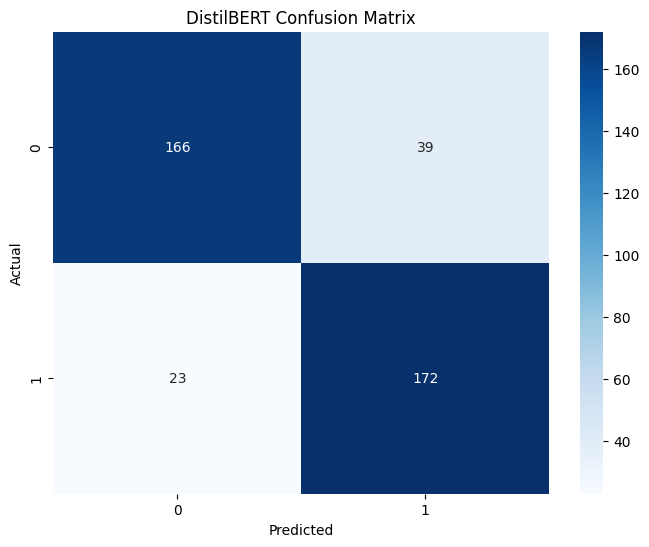

In [16]:
# ==============================
# 16) CONFUSION MATRIX
# ==============================

cm = confusion_matrix(val_labels, distil_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("DistilBERT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
# ==============================
# 17) TOKENIZE FOR BERT
# ==============================

bert_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

train_encodings_bert = bert_tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings_bert = bert_tokenizer(val_texts, truncation=True, padding=True, max_length=128)

train_dataset_bert = TextDataset(train_encodings_bert, train_labels)
val_dataset_bert = TextDataset(val_encodings_bert, val_labels)

print("BERT tokenization complete!")

BERT tokenization complete!


In [18]:
# ==============================
# 18) LOAD BERT MODEL
# ==============================

bert_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_labels
)

print("BERT model loaded!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded!


In [19]:
# ==============================
# 19) BERT TRAINING SETTINGS
# ==============================

bert_args = TrainingArguments(
    output_dir="./bert_results",
    num_train_epochs=1,              # only 1 epoch to save time
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir="./logs_bert",
    logging_steps=20,
    save_strategy="no",
    eval_strategy="epoch",
    report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [20]:
# ==============================
# 20) TRAIN BERT
# ==============================

bert_trainer = Trainer(
    model=bert_model,
    args=bert_args,
    train_dataset=train_dataset_bert,
    eval_dataset=val_dataset_bert
)

print("Training BERT...")
bert_trainer.train()
print("BERT training completed!")

Training BERT...


Epoch,Training Loss,Validation Loss
1,0.387791,0.375807


BERT training completed!


In [21]:
# ==============================
# 21) EVALUATE BERT
# ==============================

bert_preds = bert_trainer.predict(val_dataset_bert)
bert_y_pred = np.argmax(bert_preds.predictions, axis=1)

bert_acc = accuracy_score(val_labels, bert_y_pred)
bert_precision, bert_recall, bert_f1, _ = precision_recall_fscore_support(
    val_labels, bert_y_pred, average="weighted"
)

print("===== BERT RESULTS =====")
print("Accuracy :", bert_acc)
print("Precision:", bert_precision)
print("Recall   :", bert_recall)
print("F1 Score :", bert_f1)

print("\nClassification Report:")
print(classification_report(val_labels, bert_y_pred))

===== BERT RESULTS =====
Accuracy : 0.8525
Precision: 0.8642039641943734
Recall   : 0.8525
F1 Score : 0.8516901960784314

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.77      0.84       205
           1       0.80      0.94      0.86       195

    accuracy                           0.85       400
   macro avg       0.86      0.85      0.85       400
weighted avg       0.86      0.85      0.85       400



In [22]:
# ==============================
# 22) COMPARE RESULTS
# ==============================

results_df = pd.DataFrame({
    "Model": ["DistilBERT", "BERT"],
    "Accuracy": [distil_acc, bert_acc],
    "Precision": [distil_precision, bert_precision],
    "Recall": [distil_recall, bert_recall],
    "F1 Score": [distil_f1, bert_f1]
})

print(results_df)
results_df

        Model  Accuracy  Precision  Recall  F1 Score
0  DistilBERT    0.8450   0.847526  0.8450  0.844907
1        BERT    0.8525   0.864204  0.8525  0.851690


,Model,Accuracy,Precision,Recall,F1 Score
0,DistilBERT,0.8450,0.847526,0.8450,0.844907
1,BERT,0.8525,0.864204,0.8525,0.851690


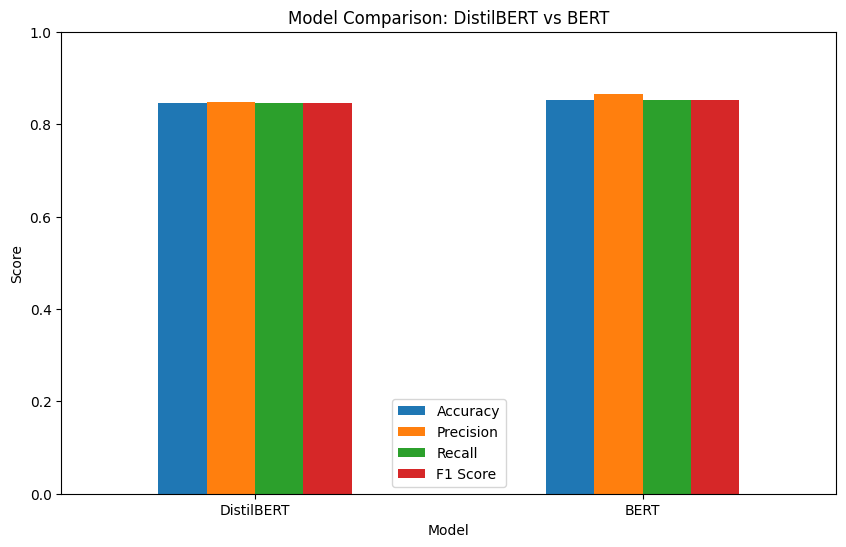

In [23]:
# ==============================
# 23) VISUAL COMPARISON
# ==============================

results_df.set_index("Model").plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison: DistilBERT vs BERT")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()